# Exploratory Data Analysis (EDA)

## Project: Brazilian E-Commerce Sales Analysis

### Objectives
- Analyze sales trends
- Analyze customer behavior
- Analyze payment methods
- Analyze product performance
- Analyze seller performance
- Generate business insights

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("../dataset/clean_data/customers_clean.csv")
orders = pd.read_csv("../dataset/clean_data/orders_clean.csv")
order_items = pd.read_csv("../dataset/clean_data/order_items_clean.csv")
payments = pd.read_csv("../dataset/clean_data/payments_clean.csv")
products = pd.read_csv("../dataset/clean_data/products_clean.csv")
sellers = pd.read_csv("../dataset/clean_data/sellers_clean.csv")
reviews = pd.read_csv("../dataset/clean_data/reviews_clean.csv")
geolocation = pd.read_csv("../dataset/clean_data/geolocation_clean.csv")
translation = pd.read_csv("../dataset/clean_data/translation_clean.csv")

In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [4]:
print("Total Orders:", orders["order_id"].nunique())

Total Orders: 99441


In [5]:
print("Total Customers:", customers["customer_unique_id"].nunique())

Total Customers: 96096


In [6]:
total_revenue = order_items["price"].sum()

print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 13591643.7


In [7]:
average_order_value = order_items["price"].mean()

print("Average Product Price:", round(average_order_value, 2))

Average Product Price: 120.65


## MONTHLY ORDER TREND

In [8]:
orders["Year_Month"] = orders["order_purchase_timestamp"].dt.to_period("M")

In [9]:
monthly_orders = (
    orders.groupby("Year_Month")
    .size()
    .reset_index(name="Total_Orders")
)

monthly_orders.head()

,Year_Month,Total_Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


## GRAPH

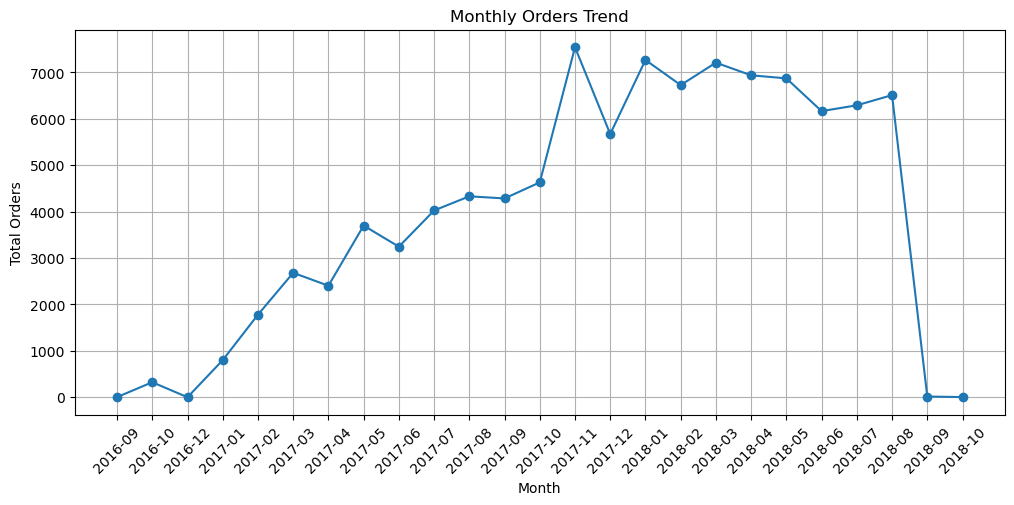

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders["Year_Month"].astype(str),
    monthly_orders["Total_Orders"],
    marker="o"
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()